In [1]:
import pandas as pd

orders = pd.read_csv("olist_orders_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

print(orders.shape)
print(orders.head())

(99441, 8)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00       

In [2]:
# Join orders with reviews (one review per order)
merged = orders.merge(reviews, on="order_id", how="left")

# Join that with customers (to get the state)
merged = merged.merge(customers, on="customer_id", how="left")

print(merged.shape)
merged.head()

(99992, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [3]:
# Check which order_ids have more than one review
review_counts = reviews["order_id"].value_counts()
duplicated_orders = review_counts[review_counts > 1]
print(duplicated_orders)

order_id
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
843be4a0dcdb9716de7652d53af4acab    2
                                   ..
fd61441ba2a7b57e6342862e779b10b0    2
4703440eb9289d3769819920e98ec061    2
3c5c2cfeea91d9a57ac3c979ec6c9d62    2
74b7f4373a78df8c16862d9d0875c5b4    2
d22f0b06e1519065d7eddb2ba6b79b63    2
Name: count, Length: 547, dtype: int64


In [4]:
# Sort so the newest review comes first, then keep only the first review per order
reviews_clean = reviews.sort_values("review_creation_date", ascending=False)
reviews_clean = reviews_clean.drop_duplicates(subset="order_id", keep="first")

# Redo the merge with the cleaned reviews
merged = orders.merge(reviews_clean, on="order_id", how="left")
merged = merged.merge(customers, on="customer_id", how="left")

print(merged.shape)


(99441, 18)


In [5]:
# Convert the date columns from text into real dates
merged["order_estimated_delivery_date"] = pd.to_datetime(merged["order_estimated_delivery_date"])
merged["order_delivered_customer_date"] = pd.to_datetime(merged["order_delivered_customer_date"])

# Calculate the difference in days
merged["days_difference"] = (merged["order_estimated_delivery_date"] - merged["order_delivered_customer_date"]).dt.days

print(merged["days_difference"].describe())

count    96476.000000
mean        10.876881
std         10.183854
min       -189.000000
25%          6.000000
50%         11.000000
75%         16.000000
max        146.000000
Name: days_difference, dtype: float64


In [6]:
# Classify delivery status
def classify_delay(days):
    if pd.isna(days):
        return "Not Delivered"
    elif days >= 0:
        return "On Time"
    elif days >= -5:
        return "Late"
    else:
        return "Super Late"

merged["delivery_status"] = merged["days_difference"].apply(classify_delay)

print(merged["delivery_status"].value_counts())

delivery_status
On Time          88649
Super Late        4212
Late              3615
Not Delivered     2965
Name: count, dtype: int64


In [7]:
# Only look at delivered orders (exclude "Not Delivered")
delivered = merged[merged["delivery_status"] != "Not Delivered"]

# For each state, calculate % of orders that are Late or Super Late
state_summary = delivered.groupby("customer_state")["delivery_status"].apply(
    lambda x: (x.isin(["Late", "Super Late"])).mean() * 100
).sort_values(ascending=False)

print(state_summary)

customer_state
AL    23.929471
MA    19.665272
PI    15.966387
CE    15.324472
SE    15.223881
BA    14.035627
RJ    13.470412
TO    12.773723
PA    12.367865
ES    12.230576
RR    12.195122
MS    11.554922
PB    11.025145
PE    10.797238
RN    10.759494
SC     9.754722
GO     8.175779
RS     7.148204
DF     7.067308
MT     6.772009
SP     5.894555
MG     5.618670
PR     4.996953
AP     4.477612
AM     4.137931
AC     3.750000
RO     2.880658
Name: delivery_status, dtype: float64


In [8]:
# Average review score by delivery status
review_by_status = merged.groupby("delivery_status")["review_score"].mean()
print(review_by_status)

delivery_status
Late             3.460482
Not Delivered    1.747098
On Time          4.293916
Super Late       1.785296
Name: review_score, dtype: float64


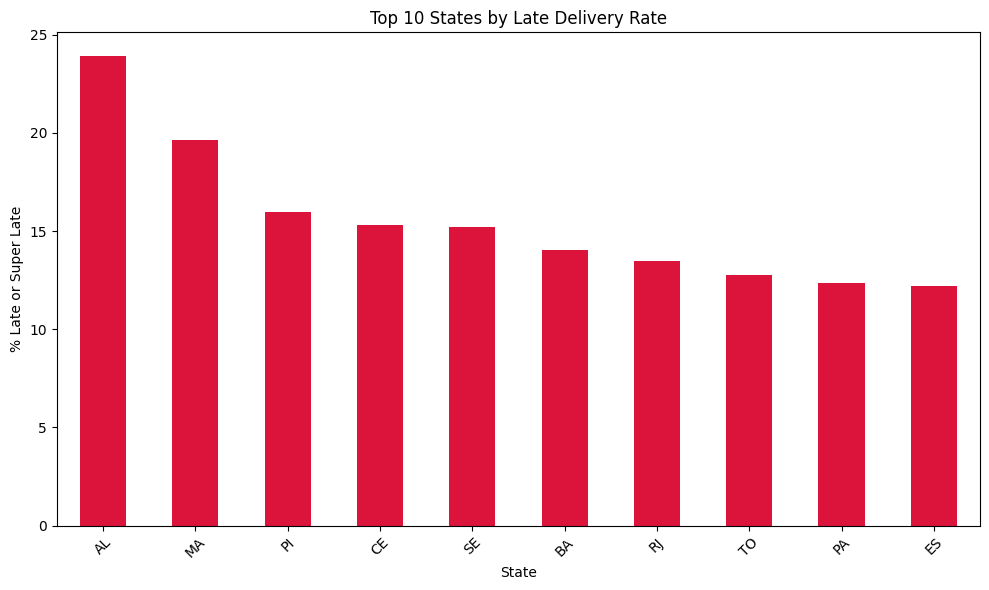

In [9]:
import matplotlib.pyplot as plt

# Take the top 10 worst states for a clear chart
top_states = state_summary.head(10)

plt.figure(figsize=(10, 6))
top_states.plot(kind="bar", color="crimson")
plt.title("Top 10 States by Late Delivery Rate")
plt.xlabel("State")
plt.ylabel("% Late or Super Late")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

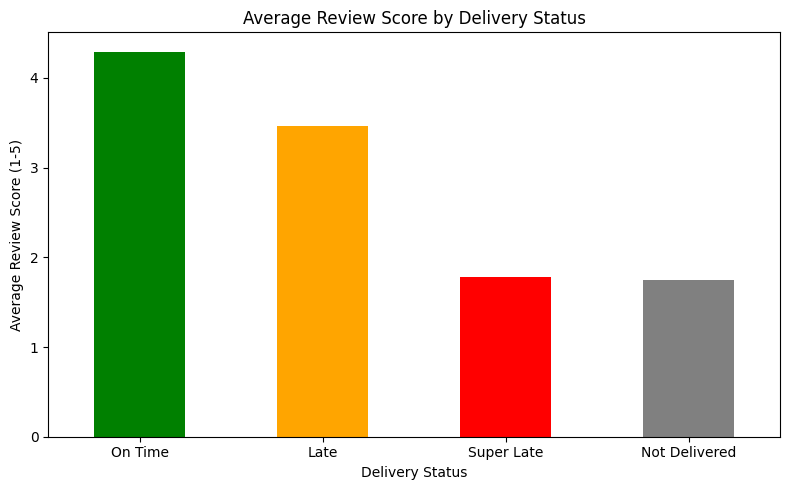

In [11]:
order = ["On Time", "Late", "Super Late", "Not Delivered"]
review_by_status_ordered = review_by_status.reindex(order)

plt.figure(figsize=(8, 5))
review_by_status_ordered.plot(kind="bar", color=["green", "orange", "red", "gray"])
plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score (1-5)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
order_items = pd.read_csv("olist_order_items_dataset.csv")

print(order_items.shape)
order_items.head()

(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [13]:
# Keep only the first item per order, to avoid duplicating rows again
order_items_clean = order_items.drop_duplicates(subset="order_id", keep="first")

# Link order_id to product_id
merged = merged.merge(order_items_clean[["order_id", "product_id"]], on="order_id", how="left")

# Link product_id to category name
merged = merged.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")

# Translate category name to English
merged = merged.merge(translation, on="product_category_name", how="left")

print(merged.shape)
merged[["product_category_name", "product_category_name_english"]].head()

(99441, 23)


,product_category_name,product_category_name_english
0,utilidades_domesticas,housewares
1,perfumaria,perfumery
2,automotivo,auto
3,pet_shop,pet_shop
4,papelaria,stationery


In [14]:
# Only look at delivered orders (exclude "Not Delivered")
delivered_products = merged[merged["delivery_status"] != "Not Delivered"]

# For each category, calculate % of orders that are Late or Super Late
category_summary = delivered_products.groupby("product_category_name_english")["delivery_status"].apply(
    lambda x: (x.isin(["Late", "Super Late"])).mean() * 100
)

# Only keep categories with a reasonable number of orders, so the % isn't based on just 1-2 orders
category_counts = delivered_products["product_category_name_english"].value_counts()
reliable_categories = category_counts[category_counts >= 100].index

category_summary = category_summary[reliable_categories].sort_values(ascending=False)

print(category_summary.head(10))

product_category_name_english
audio                              13.081395
fashion_underwear_beach            12.820513
books_technical                    10.980392
home_confort                       10.270270
food                               10.114943
electronics                         9.852413
christmas_supplies                  9.600000
baby                                9.337676
office_furniture                    9.229535
construction_tools_construction     9.203297
Name: delivery_status, dtype: float64


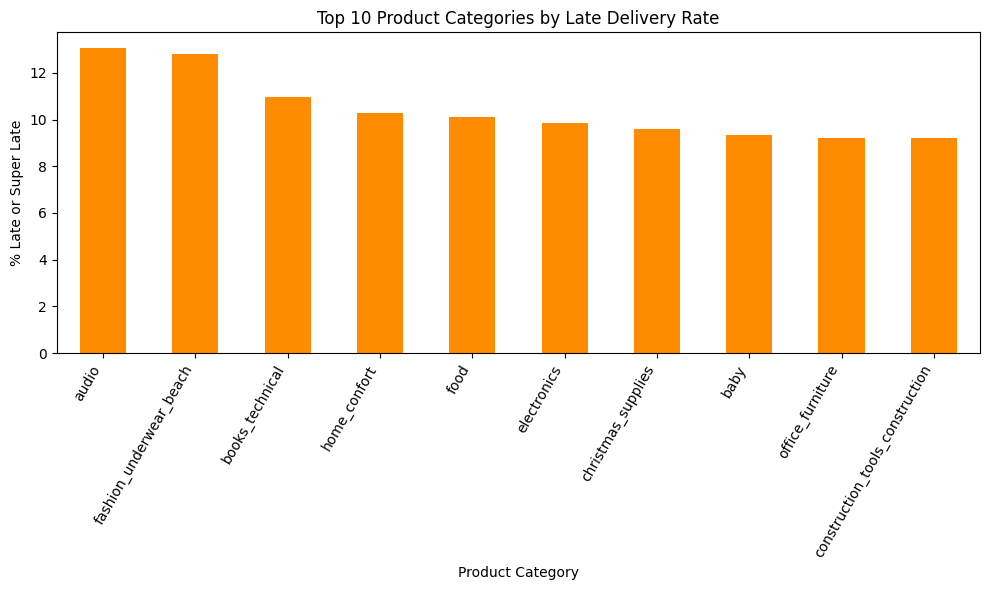

In [15]:
plt.figure(figsize=(10, 6))
category_summary.head(10).plot(kind="bar", color="darkorange")
plt.title("Top 10 Product Categories by Late Delivery Rate")
plt.xlabel("Product Category")
plt.ylabel("% Late or Super Late")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [16]:
# Keep only the columns useful for the dashboard, to keep it light
dashboard_data = merged[[
    "order_id",
    "customer_state",
    "order_purchase_timestamp",
    "days_difference",
    "delivery_status",
    "review_score",
    "product_category_name_english"
]]

dashboard_data.to_csv("dashboard_data.csv", index=False)
print("Saved:", dashboard_data.shape)

Saved: (99441, 7)
